# Autres méthodes

## Imports & Variables

In [1]:
import os
import sys
sys.path.append(os.path.abspath("../../../"))

from src.methodes import *
from src.visualisations import *
from src.data import charger_dossier, charger_fichier

In [2]:
valeur_de_travail = 'niveau_nappe_eau'

fichier_nappe = "../../../data/fusion/data_03288X0042_P.csv"
fichier_nappe = "../../../data/fusion/data_02936X1018_P.csv"
#fichier_nappe = "../../../data/fusion/data_03276X0009_P.csv"

#fichier_nappe = "../../../data/fusion/data_03287X0018_S1.csv"

dossier_nappe = "../../../data/fusion"


df = charger_fichier(fichier_nappe)

## Random forest

La Random Forest construit plusieurs arbres de décision sur des échantillons différents du jeu de données. Chaque arbre fait une prédiction indépendante. Pour la régression, la Random Forest prend la moyenne des prédictions de tous les arbres. Chaque arbre utilise seulement un sous-ensemble aléatoire de variables à chaque décision, ce qui rend le modèle plus robuste et réduit le risque de surapprentissage.

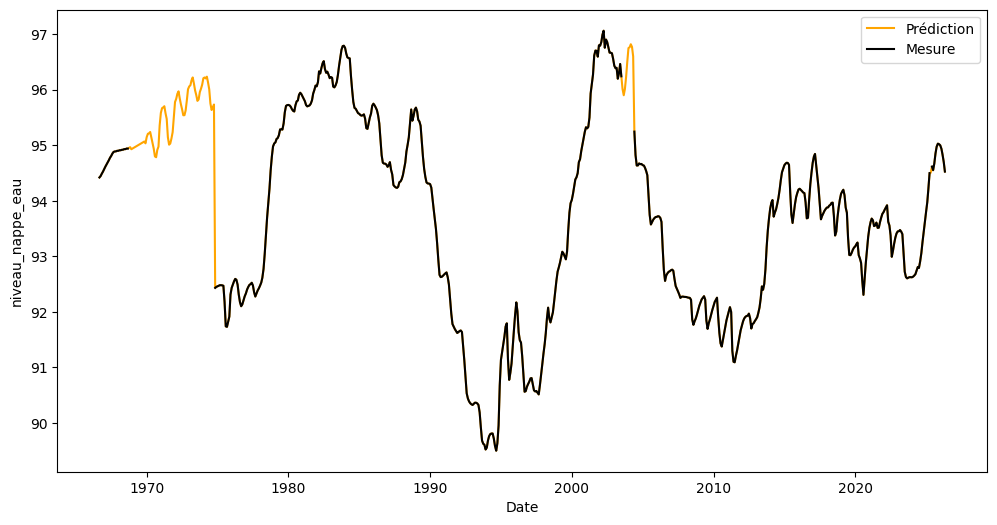

In [4]:
affiche_prediction(df, random_forest_delta_array(df, valeur_de_travail), valeur_de_travail)

## KNN

La méthode des K plus proches voisins (KNN) permet d’estimer la valeur d’un point en regardant les K points les plus proches dans le jeu de données.
Pour la régression, on prend la moyenne des valeurs de ces voisins, et pour la classification, on prend la classe la plus fréquente.
La distance entre les points est souvent calculée avec la distance Euclidienne.

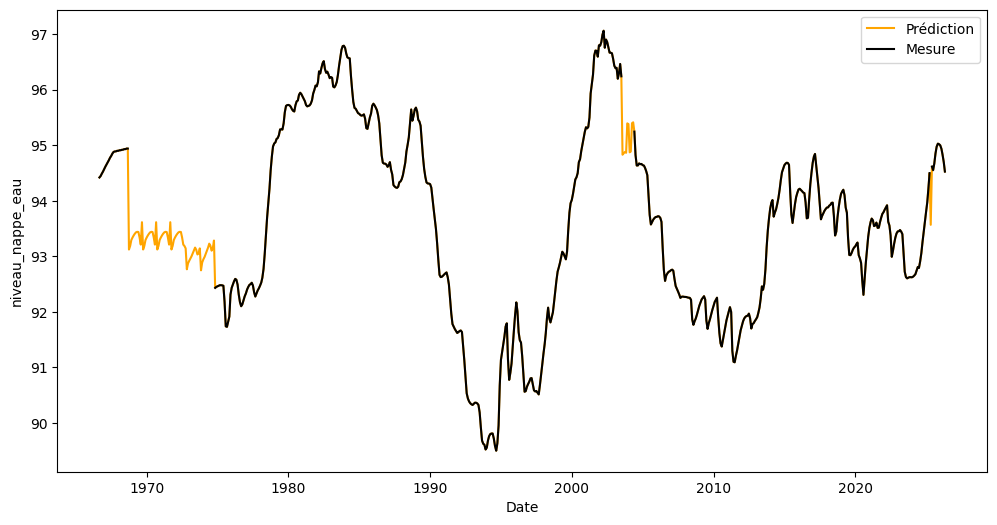

In [3]:
affiche_prediction(df, knn_impute(df, valeur_de_travail), valeur_de_travail)

## Bootstrap saisonnier

La méthode d’imputation saisonnière par profil historique consiste à remplir les valeurs manquantes d’une série temporelle en utilisant les comportements passés ou futur de la variable. Pour chaque jour de l’année, on calcule la valeur typique, par exemple la médiane sur toutes les années disponibles, puis on remplace les données manquantes par cette valeur correspondant au mois considéré.

In [ ]:
affiche_prediction(df, bootstrap_saisonnier_impute(df, valeur_de_travail), valeur_de_travail)

## Complétion par similarité via transformer de Fourier

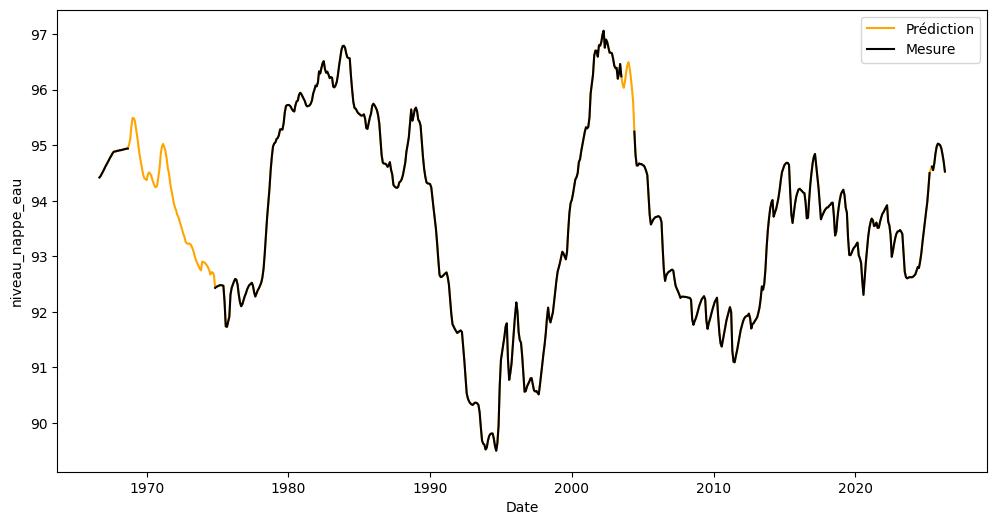

In [3]:
affiche_prediction(df, knn_nappe(df, charger_dossier(dossier_nappe),valeur_de_travail, n_top=10), valeur_de_travail)